1. What is a Support Vector Machine (SVM)?
  - SVM is a ML algorithm used for classification and regression problem.

2. What is the difference between Hard Margin and Soft Margin SVM?
  - When no data points lie between the marginal lines, it is called hard margin.
  - When some data points lie between the marginal lines, it is called soft margin.

3. What is the mathematical intuition behind SVM?
  - SVM tries to find hyperplane to seperate classes with maximum margin.

4. What is the role of Lagrange Multipliers in SVM?
  - In SVM, Lagrange multipliers make sure the rules are followed and decide which points are important (support vectors).

5. What are Support Vectors in SVM?
  - The data points through which marginal line passes are called support vectors.

6. What is a Support Vector Classifier (SVC)?
  - SVC is an ML algorithm used for classification problems.

7. What is a Support Vector Regressor (SVR)?
  - SVR is an ML algorithm used for regression problems.

8. What is the Kernel Trick in SVM?
  - If classes can't be seperated in current dimension, it can be seperated in higher dimension.

9.  Compare Linear Kernel, Polynomial Kernel, and RBF Kernel.
  - Linear kernel can be used when classes can be seperated with linear line.
  - Polynomial kernel can be used when classes can be seperated with polynomial line.
  - RBF kernel can be used when classes can be seperated with circular line.

10.  What is the effect of the C parameter in SVM?
  - C parameter sets how many data points to be misclassified.

11.  What is the role of the Gamma parameter in RBF Kernel SVM?
  - Gamma controls how much each data point affects the decision boundary.

12.  What is the Naïve Bayes classifier, and why is it called "Naïve"?
  - It is probability based algorithm which uses bayes theorem.
  - It assumes all features are independent of each other, so it is called naive.

13. What is Bayes’ Theorem?
  - It gives probability of something given the event has occurred.

14.  Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes.
  - Gaussian Naïve Bayes is used for continuous numerical data following normal distribution.
  - Multinomial Naïve Bayes is used for count data. Used in text classification.
  - Bernoulli Naïve Bayes is used for binary data. 0 or 1.

15. When should you use Gaussian Naïve Bayes over other variants?
  - Gaussian Naïve Bayes should be used when data is continuous numerical following normal distribution.

16.  What are the key assumptions made by Naïve Bayes?
  - Features are independent to each other.
  - Each feature is equally important.

17.  What are the advantages and disadvantages of Naïve Bayes?
  - Advantages:
    - Simple and easy to understand.
    - Very fast to train and predict.
    - Works well with large datasets.
    - Performs well in text classification.
  - Disadvantages:
    - Assumes features are independent.
    - Performance drops when features are highly correlated.

18.  Why is Naïve Bayes a good choice for text classification?
  - Multinomial Naïve Bayes is used for count data.
  - Handles word frequency naturally.
  - It is fast and efficient for large text datasets.

19. Compare SVM and Naïve Bayes for classification tasks.
  - SVM finds the best seperating boundary. Training speed is slower. Less interpretable.
  - Naive Bayes finds probability. Training speed is faster. Highly interpretable.

20.  How does Laplace Smoothing help in Naïve Bayes?
  - If a word never appears in a class, so it's probability is 0.
  - To prevent 0 probability it adds a small value (usually +1) to all counts, so probabilities are never zero.

In [ ]:
# 21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

iris_data = load_iris()
X = iris_data.data
y = iris_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
# 22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then
# compare their accuracies
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

wine_data = load_wine()
X = wine_data.data
y = wine_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

kernels = ["linear", "rbf"]

for kernel in kernels:
  model = SVC(kernel=kernel)
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  print(f"{kernel} Accuracy: {accuracy}")

linear Accuracy: 1.0
rbf Accuracy: 0.8055555555555556


In [ ]:
# 23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean
# Squared Error (MSE)
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

housing_data = fetch_california_housing()
X = housing_data.data
y = housing_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVR()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 1.3320115421348744


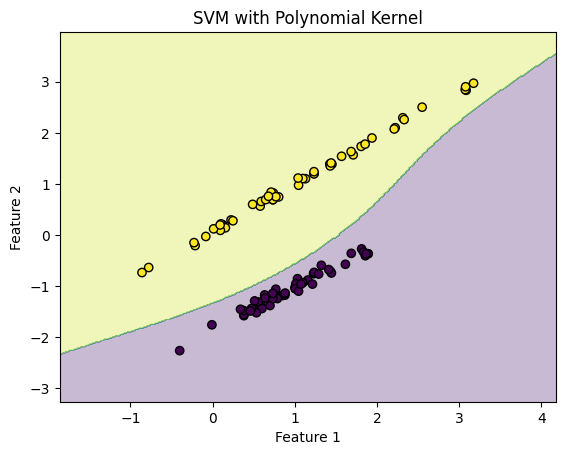

In [ ]:
# 24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision
# boundary
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100,n_features=2,n_redundant=0,n_clusters_per_class=1,random_state=42)

model = SVC(kernel='poly', degree=3, C=1)
model.fit(X, y)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM with Polynomial Kernel")
plt.show()

In [ ]:
# 25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and
# evaluate accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

breast_cancer_data = load_breast_cancer()
X = breast_cancer_data.data
y = breast_cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9736842105263158


In [ ]:
# 26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20
# Newsgroups dataset.
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

train_data = fetch_20newsgroups(subset='train')
test_data = fetch_20newsgroups(subset='test')

vectorizer = CountVectorizer(stop_words='english')
X_train = vectorizer.fit_transform(train_data.data)
X_test = vectorizer.transform(test_data.data)

model = MultinomialNB()
model.fit(X_train, train_data.target)

MultinomialNB()

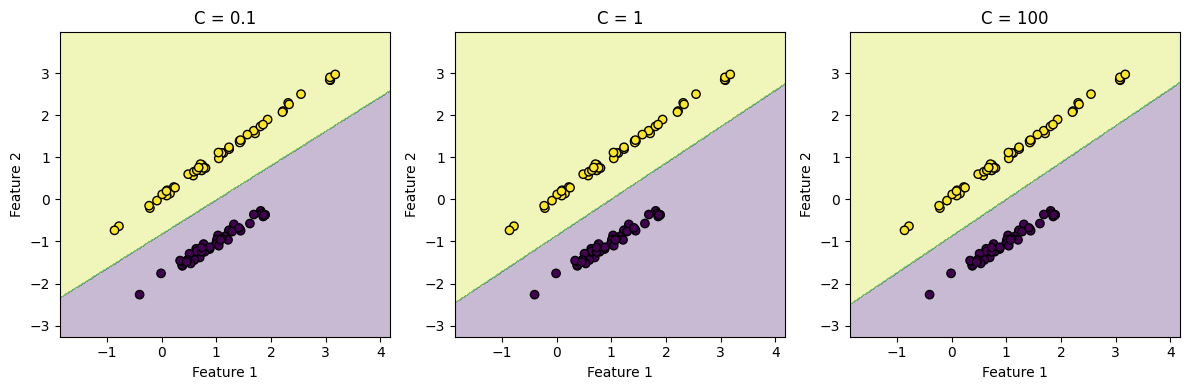

In [ ]:
# 27. Write a Python program to train an SVM Classifier with different C values and compare the decision
# boundaries visually
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

C_values = [0.1, 1, 100]

plt.figure(figsize=(12, 4))

for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X, y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(f"C = {C}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

In [ ]:
# 28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with
# binary features
import numpy as np
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split

X = np.array([
    [1, 0, 1],
    [1, 1, 0],
    [0, 1, 1],
    [0, 0, 1],
    [1, 0, 0],
    [0, 1, 0]
])

y = np.array([1, 1, 0, 0, 1, 0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BernoulliNB()
model.fit(X_train, y_train)

BernoulliNB()

In [ ]:
# 29. Write a Python program to apply feature scaling before training an SVM model and compare results with
# unscaled data
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=5, n_informative=3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

svm_unscaled = SVC(kernel='rbf')
svm_unscaled.fit(X_train, y_train)
y_pred_unscaled = svm_unscaled.predict(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_scaled = SVC(kernel='rbf')
svm_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = svm_scaled.predict(X_test_scaled)

print("Accuracy without scaling:", accuracy_score(y_test, y_pred_unscaled))
print("Accuracy with scaling:", accuracy_score(y_test, y_pred_scaled))


Accuracy without scaling: 0.9333333333333333
Accuracy with scaling: 0.9333333333333333


In [ ]:
# 30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and
# after Laplace Smoothing
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=200, n_features=4, n_informative=3, n_redundant=0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gnb_no_smooth = GaussianNB(var_smoothing=0)
gnb_no_smooth.fit(X_train, y_train)
pred_no_smooth = gnb_no_smooth.predict(X_test)

gnb_smooth = GaussianNB(var_smoothing=100)
gnb_smooth.fit(X_train, y_train)
pred_smooth = gnb_smooth.predict(X_test)

print("Predictions without smoothing:\n", pred_no_smooth[:10])
print("\nPredictions with smoothing:\n", pred_smooth[:10])

Predictions without smoothing:
 [0 0 1 0 0 0 0 1 1 0]

Predictions with smoothing:
 [1 1 1 1 1 1 1 1 1 1]


In [ ]:
# 31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C,
# gamma, kernel)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

params = {"C": [1,2,5,10,100],
          "gamma": ["scale", "auto"],
          "kernel": ['linear', 'poly', 'rbf']}

iris_data = load_iris()
X = iris_data.data
y = iris_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GridSearchCV(SVC(), params, cv=5)
model.fit(X_train, y_train)

model.best_estimator_

SVC(C=5, kernel='linear')

In [ ]:
# 32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and
# check it improve accuracy
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=2, weights=[0.9, 0.1], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

svm_normal = SVC(kernel='poly')
svm_normal.fit(X_train, y_train)
y_pred_normal = svm_normal.predict(X_test)

svm_weighted = SVC(kernel='poly', class_weight='balanced')
svm_weighted.fit(X_train, y_train)
y_pred_weighted = svm_weighted.predict(X_test)

print("Without class weighting:")
print("Accuracy:", accuracy_score(y_test, y_pred_normal))

print("\nWith class weighting:")
print("Accuracy:", accuracy_score(y_test, y_pred_weighted))

Without class weighting:
Accuracy: 0.9233333333333333

With class weighting:
Accuracy: 0.9366666666666666


In [ ]:
# 33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

emails = [
    "Win a free lottery prize now",
    "Limited offer buy now",
    "Meeting scheduled for tomorrow",
    "Project deadline is next week",
    "Congratulations you won a prize",
    "Let us discuss the report"
]

labels = [1, 1, 0, 0, 1, 0]

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(emails)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# 34.  Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and
# compare their accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=6, n_informative=4, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

print("Naïve Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

Naïve Bayes Accuracy: 0.7266666666666667
SVM Accuracy: 0.8466666666666667


In [ ]:
# 35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare
# results
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score
import numpy as np

X, y = make_classification(n_samples=500, n_features=10, n_informative=5, random_state=42)
X = np.abs(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_full = nb.predict(X_test)

selector = SelectKBest(score_func=chi2, k=5)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

nb_selected = GaussianNB()
nb_selected.fit(X_train_selected, y_train)
y_pred_selected = nb_selected.predict(X_test_selected)

print("Accuracy without feature selection:", accuracy_score(y_test, y_pred_full))
print("Accuracy with feature selection:", accuracy_score(y_test, y_pred_selected))

Accuracy without feature selection: 0.62
Accuracy with feature selection: 0.62


In [ ]:
# 36.  Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO)
# strategies on the Wine dataset and compare their accuracy
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_ovr = SVC(kernel='rbf', decision_function_shape='ovr')
svm_ovr.fit(X_train, y_train)
y_pred_ovr = svm_ovr.predict(X_test)

svm_ovo = SVC(kernel='rbf', decision_function_shape='ovo')
svm_ovo.fit(X_train, y_train)
y_pred_ovo = svm_ovo.predict(X_test)

print("OvR Accuracy:", accuracy_score(y_test, y_pred_ovr))
print("OvO Accuracy:", accuracy_score(y_test, y_pred_ovo))

OvR Accuracy: 0.9814814814814815
OvO Accuracy: 0.9814814814814815


In [ ]:
# 37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast
# Cancer dataset and compare their accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
pred_linear = svm_linear.predict(X_test)

svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train, y_train)
pred_poly = svm_poly.predict(X_test)

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
pred_rbf = svm_rbf.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, pred_linear))
print("Polynomial Kernel Accuracy:", accuracy_score(y_test, pred_poly))
print("RBF Kernel Accuracy:", accuracy_score(y_test, pred_rbf))

Linear Kernel Accuracy: 0.9766081871345029
Polynomial Kernel Accuracy: 0.8947368421052632
RBF Kernel Accuracy: 0.9766081871345029


In [ ]:
# 38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the
# average accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
import numpy as np

X, y = load_breast_cancer(return_X_y=True)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')

print("Accuracy for each fold:", scores)
print("Average Accuracy:", np.mean(scores))

Accuracy for each fold: [0.99122807 0.94736842 0.97368421 0.99122807 0.98230088]
Average Accuracy: 0.9771619313771154


In [ ]:
# 39.  Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare
# performance
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=5, n_informative=3, weights=[0.7, 0.3], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

nb_default = GaussianNB()
nb_default.fit(X_train, y_train)
pred_default = nb_default.predict(X_test)

custom_priors = [0.5, 0.5]
nb_custom = GaussianNB(priors=custom_priors)
nb_custom.fit(X_train, y_train)
pred_custom = nb_custom.predict(X_test)

print("Accuracy with default priors:", accuracy_score(y_test, pred_default))
print("Accuracy with custom priors:", accuracy_score(y_test, pred_custom))


Accuracy with default priors: 0.9
Accuracy with custom priors: 0.9


In [ ]:
# 40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and
# compare accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

# Load dataset
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_full = SVC(kernel='linear')
svm_full.fit(X_train_scaled, y_train)
pred_full = svm_full.predict(X_test_scaled)

svm_for_rfe = SVC(kernel='linear')
rfe = RFE(estimator=svm_for_rfe, n_features_to_select=10)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

svm_rfe = SVC(kernel='linear')
svm_rfe.fit(X_train_rfe, y_train)
pred_rfe = svm_rfe.predict(X_test_rfe)

print("Accuracy without RFE:", accuracy_score(y_test, pred_full))
print("Accuracy with RFE:", accuracy_score(y_test, pred_rfe))

Accuracy without RFE: 0.9766081871345029
Accuracy with RFE: 0.9649122807017544


In [ ]:
# 41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and
# F1-Score instead of accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.9814814814814815
Recall: 0.9814814814814815
F1-Score: 0.9814814814814815


In [ ]:
# 42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss
# (Cross-Entropy Loss)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

X, y = make_classification(n_samples=500, n_features=5, n_informative=3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

nb = GaussianNB()
nb.fit(X_train, y_train)

y_prob = nb.predict_proba(X_test)

loss = log_loss(y_test, y_prob)

print("Log Loss (Cross-Entropy Loss):", loss)

Log Loss (Cross-Entropy Loss): 0.3933137074227781


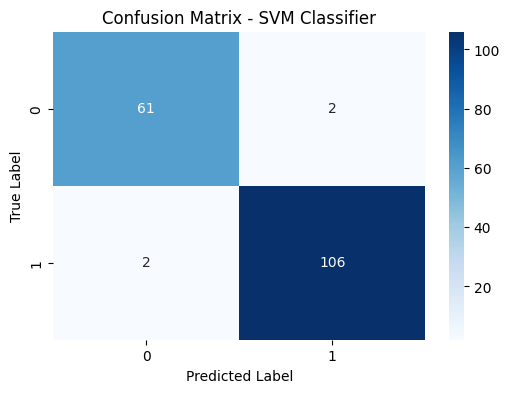

In [ ]:
# 43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Classifier")
plt.show()

In [ ]:
# 44.  Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute
# Error (MAE) instead of MSE
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

X, y = make_regression(n_samples=500, n_features=5, noise=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 73.11254462571247


In [ ]:
# 45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC
# score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

X, y = make_classification(n_samples=500, n_features=5, n_informative=3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

nb = GaussianNB()
nb.fit(X_train, y_train)

y_prob = nb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9447316812266002


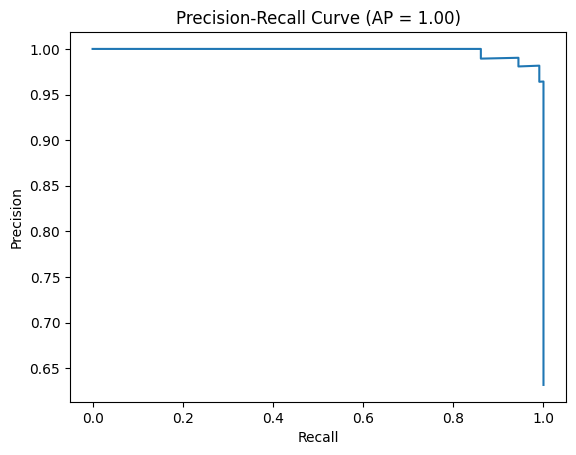

In [ ]:
# 46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, average_precision_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

y_scores = svm.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {avg_precision:.2f})")
plt.show()